# 🚛 Truck Trip Clustering Analysis using DBSCAN & KMeans

## 🧩 Project Overview

This project analyzes truck movement data to identify key transportation clusters and logistics hubs using geospatial coordinates (latitude & longitude).
The goal is to segment origin and destination points to uncover patterns in trip behavior, optimize routes, and improve supply-chain efficiency.

By applying DBSCAN and KMeans clustering, we detect high-density operational zones, major transport corridors, and potential route optimization opportunities.

## 🗂️ Dataset Description

Each record represents a unique truck trip with its origin, destination, GPS data, timings, and associated operational parameters.
Dataset Description:

- GpsProvider - Vendor who provides GPS
- BookingID - Unique Identification for a trip
- Market/Regular - Type of trip. Regular - Vendors with whom we will have contract. Market - Vendor with  - whom we will not have contract
- BookingID_Date - Date when booking was created
- vehicle_no - Truck Number
- Origin_Location - Trip start place
- Destination_Location - Trip end place
- Org_lat_lon - Latitude/Longitude of start place
- Des_lat_lon - Latitude/Longitude of end place
- Data_Ping_time - Time when we receive GPS ping
- Planned_ETA - Planned Estimated Time of Arrival
- Current_Location - Live location
- DestinationLocation - Repeat of destination location
- actual_eta - Time when the truck arrived
- Curr_lat - current latitude - changes each time when we receive GPS ping
- Curr_lon - current longitude - changes each time when we receive GPS ping
- ontime - If the truck arrived on time - calculated based on Planned and Actual ETA
- delay - If the truck arrived with a delay - calculated based on Planned and Actual ETA
- OriginLocation_Code - Origin code
- DestinationLocation_Code - Destination code
- trip_start_date - Date/Time when trip started
- trip_end_date Date/Time when trip ended - based on documentation (cant be considered for calculating delay)\
- TRANSPORTATION_DISTANCE_IN_KM - Total KM of travel
- vehicleType - Type of Truck
- Minimum_kms_to_be_covered_in_a_day - Minimum KM the driver needs to cover in a day
- Driver_Name - Driver details
- Driver_MobileNo - Driver details
- customerID - Customer details
- customerNameCode - Customer details
- supplierID - Supplier - Who provides the vehicle
- supplierNameCode - Supplier - Who provides the vehicle

In [36]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import plotly.express as px

In [37]:
truck_data = pd.read_csv('C:/Users/91701/Downloads/Truck_data/Delivery truck trip data.csv')
truck_data

C:\Users\91701\AppData\Local\Temp\ipykernel_18492\3107557400.py:1: DtypeWarning:

Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,16,17,18,19,20,21,23,25,27,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.



,GpsProvider,BookingID,Market/Regular,BookingID_Date,vehicle_no,Origin_Location,Destination_Location,Org_lat_lon,Des_lat_lon,Data_Ping_time,...,TRANSPORTATION_DISTANCE_IN_KM,vehicleType,Minimum_kms_to_be_covered_in_a_day,Driver_Name,Driver_MobileNo,customerID,customerNameCode,supplierID,supplierNameCode,Material Shipped
0,CONSENT TRACK,MVCV0000927/082021,Market,17-08-2020,KA590408,"TVSLSL-PUZHAL-HUB,CHENNAI,TAMIL NADU","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA","13.1550,80.1960","12.7400,77.8200",05:09.0,...,320.0,NaN,NaN,NaN,NaN,ALLEXCHE45,Ashok leyland limited,VIJEXHOSR7,VIJAY TRANSPORT,BRACKET / GRAB HANDLE
1,VAMOSYS,VCV00014271/082021,Regular,27-08-2020,TN30BC5917,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",40:28.0,...,103.0,NaN,NaN,RAMESH,NaN,DMREXCHEUX,Daimler india commercial vehicles pvt lt,VJLEXSHE09,VJ LOGISTICS,ZB MODEL PLATE / 3143
2,CONSENT TRACK,VCV00014382/082021,Regular,27-08-2020,TN22AR2748,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8710,79.7390","11.8710,79.7390",05:09.0,...,300.0,NaN,NaN,GIRI,NaN,LUTGCCHE06,Lucas tvs ltd,GSTEXLAK1Q,G.S. TRANSPORT,LETTERING / FUSO
3,VAMOSYS,VCV00014743/082021,Regular,28-08-2020,TN28AQ0781,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",40:31.0,...,61.0,NaN,NaN,RAVI,NaN,DMREXCHEUX,Daimler india commercial vehicles pvt lt,ARVEXNAM09,ARVINTH TRANSPORT,LU STRUT RA / RADIUS ROD
4,VAMOSYS,VCV00014744/082021,Regular,28-08-2020,TN68F1722,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8720,79.6320","11.8720,79.6320",40:29.0,...,240.0,NaN,NaN,TAMIL,NaN,LUTGCCHE06,Lucas tvs ltd,SRTEXKOR96,SR TRANSPORTS,WISHBONE / V ROD/HDT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
newtruck_data = truck_data.iloc[:6880].copy()

In [39]:
truck_data = newtruck_data
truck_data

,GpsProvider,BookingID,Market/Regular,BookingID_Date,vehicle_no,Origin_Location,Destination_Location,Org_lat_lon,Des_lat_lon,Data_Ping_time,...,TRANSPORTATION_DISTANCE_IN_KM,vehicleType,Minimum_kms_to_be_covered_in_a_day,Driver_Name,Driver_MobileNo,customerID,customerNameCode,supplierID,supplierNameCode,Material Shipped
0,CONSENT TRACK,MVCV0000927/082021,Market,17-08-2020,KA590408,"TVSLSL-PUZHAL-HUB,CHENNAI,TAMIL NADU","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA","13.1550,80.1960","12.7400,77.8200",05:09.0,...,320.0,NaN,NaN,NaN,NaN,ALLEXCHE45,Ashok leyland limited,VIJEXHOSR7,VIJAY TRANSPORT,BRACKET / GRAB HANDLE
1,VAMOSYS,VCV00014271/082021,Regular,27-08-2020,TN30BC5917,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",40:28.0,...,103.0,NaN,NaN,RAMESH,NaN,DMREXCHEUX,Daimler india commercial vehicles pvt lt,VJLEXSHE09,VJ LOGISTICS,ZB MODEL PLATE / 3143
2,CONSENT TRACK,VCV00014382/082021,Regular,27-08-2020,TN22AR2748,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8710,79.7390","11.8710,79.7390",05:09.0,...,300.0,NaN,NaN,GIRI,NaN,LUTGCCHE06,Lucas tvs ltd,GSTEXLAK1Q,G.S. TRANSPORT,LETTERING / FUSO
3,VAMOSYS,VCV00014743/082021,Regular,28-08-2020,TN28AQ0781,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",40:31.0,...,61.0,NaN,NaN,RAVI,NaN,DMREXCHEUX,Daimler india commercial vehicles pvt lt,ARVEXNAM09,ARVINTH TRANSPORT,LU STRUT RA / RADIUS ROD
4,VAMOSYS,VCV00014744/082021,Regular,28-08-2020,TN68F1722,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8720,79.6320","11.8720,79.6320",40:29.0,...,240.0,NaN,NaN,TAMIL,NaN,LUTGCCHE06,Lucas tvs ltd,SRTEXKOR96,SR TRANSPORTS,WISHBONE / V ROD/HDT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6875,JTECH,WDSBKTP42751,Regular,27-03-2019,KA219502,"Ramamurthy Nagar, Bangalore, Karnataka","Sahakaranagar P.O, Bangalore, Karnataka","13.007503209603689,77.665098855934886","13.068901840235711,77.590655738806618",20:12.0,...,12.0,25 FT Open Body 21MT,NaN,NaN,NaN,LTLEXMUM40,Larsen & toubro limited,55556,A S TRANSPORTS,TOOL KIT SET
6876,JTECH,WDSBKTP43203,Regular,31-03-2019,KA01AE9163,"Ramamurthy Nagar, Bangalore, Karnataka","Bangalore International Airport, Bangalore, Ka...","13.007503209603689,77.665098855934886","13.196312912801169,77.708156925688726",20:12.0,...,31.0,40 FT 3XL Trailer 35MT,NaN,NaN,NaN,LTLEXMUM40,Larsen & toubro limited,55556,A S TRANSPORTS,CONTROL LEVER ASSY
6877,JTECH,WDSBKTP43021,Regular,29-03-2019,KA01AE9163,"Mugabala, Bangalore Rural, Karnataka","Anekal, Bangalore, Karnataka","16.560192249175344,80.792293091599547","12.722686,77.676518",20:12.0,...,49.0,40 FT 3XL Trailer 35MT,NaN,NaN,NaN,LTLEXMUM40,Larsen & toubro limited,55556,A S TRANSPORTS,SPARE PARTS AUTOMOBILE
6878,JTECH,WDSBKTP42685,Regular,27-03-2019,KA21A3643,"Mugabala, Bangalore Rural, Karnataka","Anekal, Bangalore, Karnataka","16.560192249175344,80.792293091599547","12.896896847817695,77.712223056874862",20:12.0,...,49.0,40 FT 3XL Trailer 35MT,NaN,NaN,NaN,LTLEXMUM40,Larsen & toubro limited,55556,A S TRANSPORTS,SPARE PARTS AUTOMOBILE


In [40]:
truck_data.isnull().sum()

GpsProvider                            953
BookingID                                0
Market/Regular                           0
BookingID_Date                           0
vehicle_no                               0
Origin_Location                          0
Destination_Location                     0
Org_lat_lon                              0
Des_lat_lon                              0
Data_Ping_time                         953
Planned_ETA                              0
Current_Location                       964
DestinationLocation                      0
actual_eta                              37
Curr_lat                               953
Curr_lon                               953
ontime                                4332
delay                                 2538
OriginLocation_Code                      3
DestinationLocation_Code                27
trip_start_date                          0
trip_end_date                          194
TRANSPORTATION_DISTANCE_IN_KM          712
vehicleType

In [41]:
truck_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6880 entries, 0 to 6879
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   GpsProvider                         5927 non-null   object 
 1   BookingID                           6880 non-null   object 
 2   Market/Regular                      6880 non-null   object 
 3   BookingID_Date                      6880 non-null   object 
 4   vehicle_no                          6880 non-null   object 
 5   Origin_Location                     6880 non-null   object 
 6   Destination_Location                6880 non-null   object 
 7   Org_lat_lon                         6880 non-null   object 
 8   Des_lat_lon                         6880 non-null   object 
 9   Data_Ping_time                      5927 non-null   object 
 10  Planned_ETA                         6880 non-null   object 
 11  Current_Location                    5916 no

In [42]:
truck_data.describe()

,Curr_lat,Curr_lon,TRANSPORTATION_DISTANCE_IN_KM,Minimum_kms_to_be_covered_in_a_day,Driver_MobileNo
count,5927.000000,5927.000000,6168.000000,2820.000000,2.691000e+03
mean,18.679995,78.759745,553.856282,250.239362,8.598981e+09
std,6.075561,4.216357,758.981836,24.315485,1.131669e+09
min,8.166790,69.657698,0.000000,0.000000,6.000546e+09
25%,12.871868,76.891857,40.000000,250.000000,7.651505e+09
50%,17.470923,77.843340,160.000000,250.000000,8.930762e+09
75%,23.202009,80.018999,900.000000,250.000000,9.634981e+09
max,32.367928,95.529550,2954.700000,275.000000,1.000000e+10


## ⚙️ Data Preprocessing Steps
There is a 'Org_lat_lon' and 'Dest_lat_lon' column so we need to separate out latitude and longitude from the  origin and destination of the trucks. <br>
We need to have separate values for latitude and longitude to apply the clustering algorithms so we make columns like Org_lat and Org_long for Origin and Dest_lat and Dest_long for destination.

In [43]:
truck_data = pd.concat([truck_data, truck_data['Org_lat_lon'].str.split(',', expand=True)], axis=1)

In [44]:
truck_data.rename(columns={0: 'Org_lat', 1: 'Org_long'}, inplace=True)

In [45]:
truck_data = pd.concat([truck_data, truck_data['Des_lat_lon'].str.split(',', expand=True)], axis=1)

In [46]:
truck_data.rename(columns={0: 'Dest_lat', 1: 'Dest_long'}, inplace=True)

In [47]:
truck_data['Org_lat'] = truck_data['Org_lat'].astype(float)
truck_data['Org_long'] = truck_data['Org_long'].astype(float)
truck_data['Dest_lat'] = truck_data['Dest_lat'].astype(float)
truck_data['Dest_long'] = truck_data['Dest_long'].astype(float)

Here we have plotted all origin and destination location on the map to see if there are some invalid points example there are coordinates for water bodies location(sea, oceans etc.)

In [48]:
fig = px.scatter_mapbox( truck_data,
    lat="Org_lat",
    lon="Org_long", height=600)

fig.update_layout(mapbox_style="open-street-map")  # free tiles
fig.update_layout(title="Truck Origin Locations on Map")
fig.update_layout(
    mapbox_center={"lat": 20.5937, "lon": 78.9629},
    mapbox_zoom=4.5
)
fig.show()


In [49]:
fig = px.scatter_mapbox( truck_data,
    lat="Dest_lat",
    lon="Dest_long", height=600)

fig.update_layout(mapbox_style="open-street-map")  # free tiles
fig.update_layout(title="Truck Destination Locations on Map")
fig.update_layout(
    mapbox_center={"lat": 20.5937, "lon": 78.9629},
    mapbox_zoom=4.5
)
fig.show()

## 🧭 Clustering Approach
1. KMeans Clustering
- We fit the latitude and longitude of destination as well as origin to predict the hotspots.
- We use elbow method to find the optimal number of clusters that should be there.
- We use Silhouette score to compare how good the clustering model.

2. DBSCAN Clustering
- We fit the latitude and longitude of destination as well as origin to predict the hotspots.
- We specify parameters epsilon and min samples.
- We use Silhouette score to compare how good the clustering model.

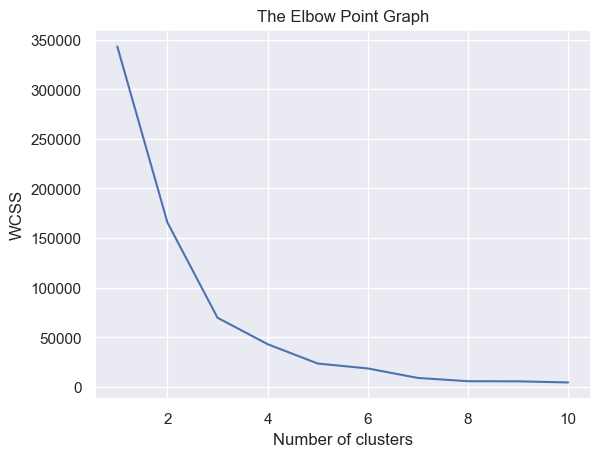

0       3
1       3
2       3
3       3
4       3
       ..
6875    5
6876    5
6877    0
6878    0
6879    0
Name: K-cluster, Length: 6880, dtype: int32


In [50]:
coords = truck_data[['Org_lat', 'Org_long']].values

WCSS = []

for i in range(1,11):
    kmeans=KMeans(n_clusters=i, init='k-means++',random_state=42)
    kmeans.fit(coords)
    WCSS.append(kmeans.inertia_)

sns.set_theme()
plt.plot(range(1,11),WCSS)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

kmeans= KMeans(n_clusters=6, init='k-means++',random_state=0)
truck_data['K-cluster'] = kmeans.fit_predict(coords)
print(truck_data['K-cluster'])

In [51]:
silhouette_score(coords, truck_data['K-cluster'])

0.7383618619334332

In [52]:
coords = StandardScaler().fit_transform(coords)
db = DBSCAN(eps=0.35, min_samples=20).fit(coords)
truck_data['DBSCAN_Cluster'] = db.labels_

In [53]:
truck_data['DBSCAN_Cluster'].unique()

array([ 0,  1, -1,  2,  3,  4,  5,  6,  7,  8], dtype=int64)

In [54]:
silhouette_score(coords, truck_data['DBSCAN_Cluster'])

0.7512784651257445

In [55]:
fig = px.scatter_mapbox(
    truck_data,
    lat="Org_lat",
    lon="Org_long",
    color="K-cluster",
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(title="Truck-Origin Clusters ")
fig.update_layout(
    mapbox_center={"lat": 20.5937, "lon": 78.9629},
    mapbox_zoom=4.5
)
fig.show()

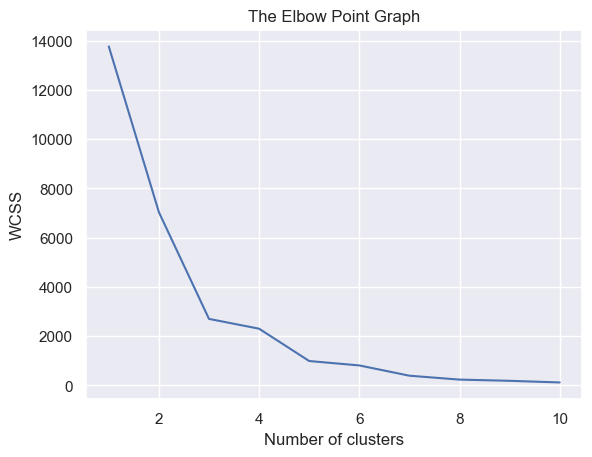

0       3
1       3
2       3
3       3
4       3
       ..
6875    5
6876    5
6877    0
6878    0
6879    0
Name: K-clusterdest, Length: 6880, dtype: int32


In [56]:
dest_coords = truck_data[['Dest_lat', 'Dest_long']].values

WCSS = []

for i in range(1,11):
    kmeans=KMeans(n_clusters=i, init='k-means++',random_state=42)
    kmeans.fit(coords)
    WCSS.append(kmeans.inertia_)

sns.set_theme()
plt.plot(range(1,11),WCSS)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

kmeans= KMeans(n_clusters=6, init='k-means++',random_state=0)
truck_data['K-clusterdest'] = kmeans.fit_predict(coords)
print(truck_data['K-clusterdest'])

In [57]:
silhouette_score(dest_coords, truck_data['K-clusterdest'])

-0.07850807885314424

In [58]:
dest_coords = StandardScaler().fit_transform(dest_coords)
db = DBSCAN(eps=0.35, min_samples=20).fit(dest_coords)
truck_data['DBSCAN_Clusterdest'] = db.labels_

In [59]:
silhouette_score(dest_coords, truck_data['DBSCAN_Clusterdest'])

0.7011220563477809

In [60]:
fig = px.scatter_mapbox(
    truck_data,
    lat="Dest_lat",
    lon="Dest_long",
    color="DBSCAN_Clusterdest",
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(title="Truck-Destination Clusters ")
fig.update_layout(
    mapbox_center={"lat": 20.5937, "lon": 78.9629},
    mapbox_zoom=4.5
)
fig.show()

- When we analyse Origin locations the Silhouette Score given by DBSCAN Algorithm is higher than score of K-Means Algorithm but when we plot on map the K-Means algorithm gives better distribution of the clusters.
- So we finally use K-Means Algorithm to analyse the Origin Location 
- When we analyzed Destination locations the Silhoutte score of K-Means is negative so that is a very bad model for clustering while DBSCAN is giving good score as well as is clearly making clusters on map.
- So we finally use DBSCAN Algorithm to analyse the Destination Location.

In [62]:
truck_data.loc[truck_data['ontime'].isna() & (truck_data['delay'] == 'R'), 'ontime'] = 'R'

When the truck is ontime the ontime value is 'G' and when truck is delay the ontime value is 'R'.<br>
Clusters with higher delays can be prioritized for route optimization or capacity planning.

In [64]:
fig = px.scatter_mapbox(
    truck_data,
    lat="Dest_lat",
    lon="Dest_long",
    color="ontime",
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(title="Clusters based on delay and ontime")
fig.update_layout(
    mapbox_center={"lat": 20.5937, "lon": 78.9629},
    mapbox_zoom=4.5
)
fig.show()

## 💡 Business Impact

- Enables route optimization by recognizing major trucking corridors.
- Helps management plan warehouse and supplier networks based on cluster density.
- Provides visibility into delivery performance by geography.
- Detects inefficient or rare routes for potential resource re-allocation.